# California Housing Price Prediction: Model Comparison Using Machine Learning


#Objective

The objective of this project was to enhance the California Housing Price Prediction system by implementing model validation techniques, overfitting analysis, and hyperparameter tuning. Multiple regression models were evaluated using RMSE and R² Score, while Cross-Validation and GridSearchCV were applied to improve model performance and select the most optimized model for prediction.


# 1. Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


# 2. Load the California Housing Dataset

In [4]:
data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [data.data, data.target.rename("HousePrice")],
    axis=1
)

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HousePrice  
0    -122.23       4.526  
1    -122.22       3.585  
2    -122.24       3.521  
3    -122.25       3.413  
4    -122.25       3.422  


#3. FEATURES & TARGET

In [5]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# 4. FEATURE SCALING

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#4. TRAIN TEST SPLIT

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

#5. MODELS

In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}


# 6. EVALUATION


MODEL COMPARISON
                       RMSE  R2 Score
Linear Regression  0.745581  0.575788
Ridge Regression   0.745554  0.575819
Decision Tree      0.724234  0.599732


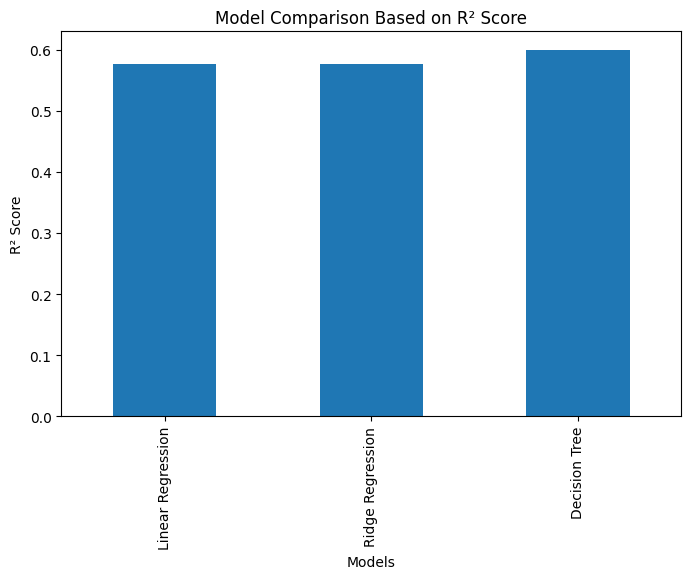

In [9]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

results_df = pd.DataFrame(results).T

print("\nMODEL COMPARISON")
print(results_df)

# Plot Comparison
results_df["R2 Score"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison Based on R² Score")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.show()

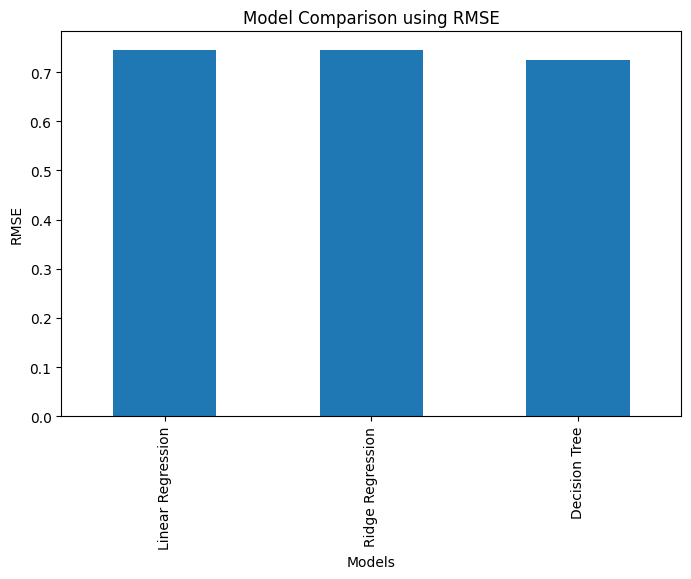

In [10]:
results_df["RMSE"].plot(kind="bar", figsize=(8,5))

plt.title("Model Comparison using RMSE")
plt.ylabel("RMSE")
plt.xlabel("Models")
plt.show()

# 7. BEST MODEL

In [11]:
best_model_name = results_df["R2 Score"].idxmax()

print("\nBest Model:", best_model_name)

best_model = models[best_model_name]



Best Model: Decision Tree


# 8. ACTUAL VS PREDICTED

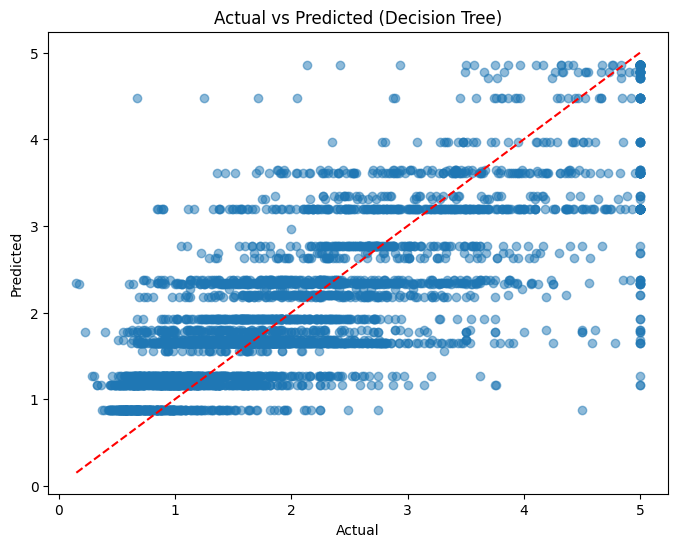

In [16]:
plt.figure(figsize=(8,6))

y_pred = best_model.predict(X_test)

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title(f"Actual vs Predicted ({best_model_name})")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()

#9. MODEL SAVED

In [17]:
import joblib

best_model_name = results_df["R2 Score"].idxmax()

best_model = models[best_model_name]

joblib.dump(best_model, "best_model.pkl")

print(f"{best_model_name} saved successfully!")

Decision Tree saved successfully!


# 10. CROSS VALIDATION

In [18]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_model,
    X_scaled,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage CV Score:")
print(cv_scores.mean())

Cross Validation Scores:
[0.32603463 0.52499182 0.60290742 0.31954034 0.53355785]

Average CV Score:
0.46140641222621015


# 11. OVERFITTING CHECK

In [19]:
train_score = best_model.score(X_train, y_train)
test_score = best_model.score(X_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 0.6376786573648903
Test Score: 0.5997321244428706


# 12. HYPERPARAMETER TUNING USING GRIDSEARCHCV

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

In [21]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [22]:
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='r2')

# 13. BEST PARAMETERS

In [23]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}

Best Cross Validation Score:
0.7104874238620574


# 14. TUNED MODEL

In [24]:
tuned_model = grid_search.best_estimator_

# 15. EVALUATE TUNED MODEL

In [25]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

tuned_predictions = tuned_model.predict(X_test)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_predictions
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)

print("Tuned RMSE:", tuned_rmse)
print("Tuned R2:", tuned_r2)

Tuned RMSE: 0.6389361233642388
Tuned R2: 0.6884641539256358


# 16. COMPARISON WITH OLD MODEL

In [26]:
original_predictions = best_model.predict(X_test)

original_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        original_predictions
    )
)

original_r2 = r2_score(
    y_test,
    original_predictions
)

comparison = pd.DataFrame({
    "Model":[
        "Original Decision Tree",
        "Tuned Decision Tree"
    ],
    "RMSE":[
        original_rmse,
        tuned_rmse
    ],
    "R2 Score":[
        original_r2,
        tuned_r2
    ]
})

comparison

,Model,RMSE,R2 Score
0,Original Decision Tree,0.724234,0.599732
1,Tuned Decision Tree,0.638936,0.688464


# 17. SAVE TUNED MODEL

In [27]:
import joblib

joblib.dump(
    tuned_model,
    "tuned_decision_tree.pkl"
)

print("Tuned model saved successfully")

Tuned model saved successfully


TASK 3 ENHANCEMENTS

1. Performed Cross-Validation to obtain reliable performance estimates.

2. Conducted Overfitting Analysis by comparing train and test scores.

3. Applied GridSearchCV for hyperparameter tuning of the Decision Tree Regressor.

4. Evaluated the tuned model using RMSE and R² Score.

5. Selected and saved the optimized model for deployment.